# Probability and Statistics course - Final project
## MNIST maximum likelihood classifier

Load and explore the MNIST handwritten digits dataset.

## Analytical derivation — Maximum‑Likelihood classifier

---

### Notation

| Symbol | Meaning |
|---|---|
| $\mathbf{x} \in \mathbb{R}^d$ | one flattened image, $d = 28\!\times\!28 = 784$ |
| $y \in \{0,\dots,9\}$ | digit label |
| $\mathcal{D} = \{(\mathbf{x}^{(n)}, y^{(n)})\}_{n=1}^{N}$ | training set, $N = 60\,000$ |
| $\mathcal{D}_c = \{(\mathbf{x}^{(n)}\!, y^{(n)}) \in \mathcal{D} \mid y^{(n)}\! = c\}$ | samples of class $c$ |
| $N_c = |\mathcal{D}_c|$ | number of training samples in class $c$ |

---

### 1.  Class‑conditional Gaussian model

We assume that, for each digit $c$, the image vectors are drawn from a
$d$‑variate Gaussian (normal) distribution:

$$\boxed{
p(\mathbf{x} \mid y=c) \;=\; \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_c,\, \boldsymbol{\Sigma}_c)
\;=\; \frac{1}{(2\pi)^{d/2}\,|\boldsymbol{\Sigma}_c|^{1/2}}
\exp\!\Bigl(-\tfrac12 (\mathbf{x}-\boldsymbol{\mu}_c)^{\mathsf{T}}
\boldsymbol{\Sigma}_c^{-1}(\mathbf{x}-\boldsymbol{\mu}_c)\Bigr)
}$$

where $\boldsymbol{\mu}_c \in \mathbb{R}^d$ is the class mean and
$\boldsymbol{\Sigma}_c \in \mathbb{R}^{d\times d}$ (symmetric, positive definite)
is the class covariance matrix.

---

### 2.  Maximum‑Likelihood estimation of $\boldsymbol{\mu}_c$ and $\boldsymbol{\Sigma}_c$

For a fixed class $c$, the log‑likelihood of the data in $\mathcal{D}_c$ is

$$
\begin{aligned}
\ell_c(\boldsymbol{\mu}_c,\boldsymbol{\Sigma}_c)
&= \sum_{\mathbf{x}^{(n)} \in \mathcal{D}_c}
\log p(\mathbf{x}^{(n)} \mid \boldsymbol{\mu}_c,\boldsymbol{\Sigma}_c) \\[4pt]
&= -\frac{N_c}{2}\Bigl[d\log(2\pi) + \log|\boldsymbol{\Sigma}_c|\Bigr]
- \frac12 \sum_{n\in\mathcal{D}_c}
(\mathbf{x}^{(n)}-\boldsymbol{\mu}_c)^{\mathsf{T}}
\boldsymbol{\Sigma}_c^{-1}(\mathbf{x}^{(n)}-\boldsymbol{\mu}_c) .
\end{aligned}
$$

#### 2a.  MLE for the mean $\boldsymbol{\mu}_c$

Setting $\nabla_{\boldsymbol{\mu}_c}\ell_c = \mathbf{0}$ yields

$$
\frac{\partial \ell_c}{\partial \boldsymbol{\mu}_c}
= \boldsymbol{\Sigma}_c^{-1}\sum_{n\in\mathcal{D}_c}
(\mathbf{x}^{(n)}-\boldsymbol{\mu}_c) = \mathbf{0}
\quad\Longrightarrow\quad
\boxed{\hat{\boldsymbol{\mu}}_c = \frac{1}{N_c}\sum_{n\in\mathcal{D}_c} \mathbf{x}^{(n)}}
$$

The MLE of the mean is simply the **sample mean** of the training images
belonging to class $c$.

#### 2b.  MLE for the covariance $\boldsymbol{\Sigma}_c$

We differentiate w.r.t. $\boldsymbol{\Sigma}_c^{-1}$ (or, equivalently,
w.r.t. $\boldsymbol{\Sigma}_c$ using the chain rule for the log‑determinant
and the quadratic form):

$$
\frac{\partial \ell_c}{\partial \boldsymbol{\Sigma}_c^{-1}}
= \frac{N_c}{2}\boldsymbol{\Sigma}_c
- \frac12 \sum_{n\in\mathcal{D}_c}
(\mathbf{x}^{(n)}-\hat{\boldsymbol{\mu}}_c)(\mathbf{x}^{(n)}-\hat{\boldsymbol{\mu}}_c)^{\mathsf{T}}
= \mathbf{0}
$$

$$
\boxed{
\hat{\boldsymbol{\Sigma}}_c = \frac{1}{N_c}
\sum_{n\in\mathcal{D}_c}
(\mathbf{x}^{(n)}-\hat{\boldsymbol{\mu}}_c)(\mathbf{x}^{(n)}-\hat{\boldsymbol{\mu}}_c)^{\mathsf{T}}
}
$$

The MLE of the covariance is the **sample (scatter) covariance** of the
training images in class $c$.

> **Regularisation.**  Because $d=784$ is large, $\hat{\boldsymbol{\Sigma}}_c$
> may be ill‑conditioned or singular (e.g. when $N_c < d$).  We add a small
> diagonal perturbation to guarantee invertibility and numerical stability:
> $$\hat{\boldsymbol{\Sigma}}_c^{\text{reg}} = \hat{\boldsymbol{\Sigma}}_c + \varepsilon \mathbf{I}_d,\qquad \varepsilon = 10^{-4}.$$

---

### 3.  Prior probabilities

The class prior is estimated by the empirical frequency:

$$\boxed{P(y=c) = \frac{N_c}{N}} \qquad\text{with}\quad \sum_{c=0}^{9} P(y=c) = 1.$$

---

### 4.  Classification via Maximum‑a‑Posteriori (MAP)

Given a new (test) image $\mathbf{x}$ we assign the label that maximises
the posterior probability.  Using Bayes’ rule and taking the logarithm:

$$
\begin{aligned}
\hat y &= \underset{c\in\{0,\dots,9\}}{\arg\!\max}\;
p(y=c \mid \mathbf{x}) \\
&= \underset{c}{\arg\!\max}\;
\log p(\mathbf{x} \mid y=c) + \log P(y=c) \\
&= \underset{c}{\arg\!\max}\;
\underbrace{\Bigl[-\tfrac12 d\log(2\pi)
- \tfrac12\log|\hat{\boldsymbol{\Sigma}}_c|
- \tfrac12 (\mathbf{x}-\hat{\boldsymbol{\mu}}_c)^{\mathsf{T}}
\hat{\boldsymbol{\Sigma}}_c^{-1}(\mathbf{x}-\hat{\boldsymbol{\mu}}_c)\Bigr]}_{\text{log‑likelihood for class }c}
+ \;\log\!\Bigl(\frac{N_c}{N}\Bigr) .
\end{aligned}
$$

Dropping the constant $\tfrac12 d\log(2\pi)$ (same for all classes)
gives the compact decision rule

$$
\boxed{
\hat y = \underset{c}{\arg\!\min}\;
\frac12\log|\hat{\boldsymbol{\Sigma}}_c|
+ \frac12\,M_c(\mathbf{x})
- \log N_c
}
$$

where

$$
M_c(\mathbf{x}) = (\mathbf{x}-\hat{\boldsymbol{\mu}}_c)^{\mathsf{T}}
\hat{\boldsymbol{\Sigma}}_c^{-1}(\mathbf{x}-\hat{\boldsymbol{\mu}}_c)
$$

is the **squared Mahalanobis distance** between the image $\mathbf{x}$ and
the class centroid $\hat{\boldsymbol{\mu}}_c$.

---

### 5.  Implementation summary

1. **Normalise** pixel intensities to $[0,1]$.
2. For each class $c=0,\dots,9$:
   - $\hat{\boldsymbol{\mu}}_c$ ← sample mean (MLE)
   - $\hat{\boldsymbol{\Sigma}}_c$ ← sample covariance + $10^{-4}\mathbf{I}$ (MLE, regularised)
   - Pre‑compute $\hat{\boldsymbol{\Sigma}}_c^{-1}$ and $\log|\hat{\boldsymbol{\Sigma}}_c|$
3. For each test image $\mathbf{x}$:
   - Compute $M_c(\mathbf{x})$ for every $c$
   - Predict $\hat y = \arg\!\min_c \bigl[\tfrac12\log|\hat{\boldsymbol{\Sigma}}_c| + \tfrac12 M_c(\mathbf{x}) - \log N_c\bigr]$

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='liac-arff')

X = X.astype(np.float32)
y = y.astype(np.int64)

print(f'Images shape: {X.shape}')
print(f'Labels shape: {y.shape}')
print(f'Pixel range: [{X.min()}, {X.max()}]')
print(f'Labels: {np.unique(y)}')

Images shape: (70000, 784)
Labels shape: (70000,)
Pixel range: [0.0, 255.0]
Labels: [0 1 2 3 4 5 6 7 8 9]


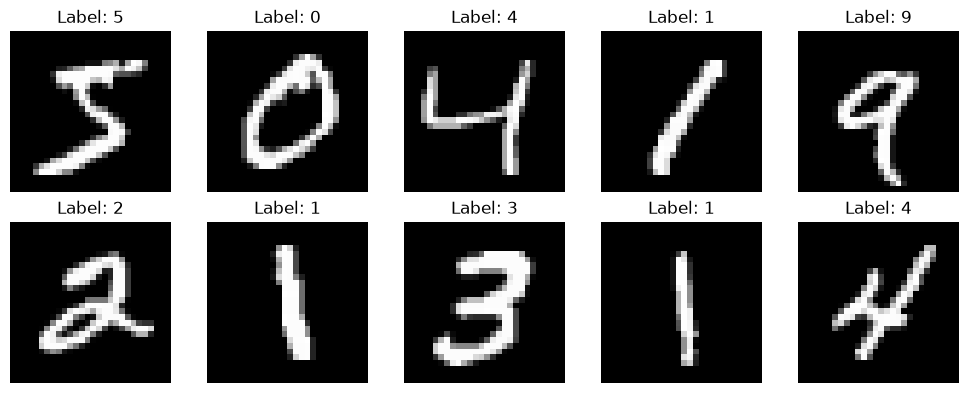

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

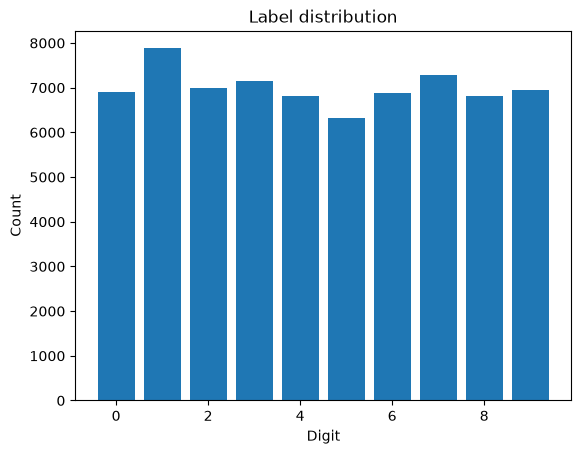

In [3]:
unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Label distribution')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 60000 samples
Test:  10000 samples


In [5]:
# --------------------------------------------------------------------
# 1.  Normalize the data so every image lies in R^784 with pixels in [0,1]
# --------------------------------------------------------------------
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

print(f'Train pixel range: [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]')
print(f'Test  pixel range: [{X_test_norm.min():.3f},  {X_test_norm.max():.3f}]')

Train pixel range: [0.000, 1.000]
Test  pixel range: [0.000,  1.000]


In [6]:
# --------------------------------------------------------------------
# 2.  Maximum‑Likelihood parameter estimation
#     Fit a class‑conditional multivariate Gaussian for each digit 0–9
#     p(x | y=c) = N(x ; μ_c , Σ_c)
# --------------------------------------------------------------------

classes    = np.unique(y_train)
n_classes  = len(classes)
n_features = X_train_norm.shape[1]          # 784

reg = 1e-4   # regularise Σ to keep it non‑singular

means   = np.zeros((n_classes, n_features))
covs    = np.zeros((n_classes, n_features, n_features))
priors  = np.zeros(n_classes)

for i, c in enumerate(classes):
    X_c        = X_train_norm[y_train == c]
    means[i]   = X_c.mean(axis=0)
    covs[i]    = np.cov(X_c, rowvar=False) + reg * np.eye(n_features)
    priors[i]  = len(X_c) / len(y_train)

print(f'Means shape:   {means.shape}')
print(f'Covs shape:    {covs.shape}')
print(f'Priors:        {priors.round(4)}')
print(f'Sum of priors: {priors.sum():.4f}')

Means shape:   (10, 784)
Covs shape:    (10, 784, 784)
Priors:        [0.0986 0.1125 0.0998 0.102  0.0975 0.0902 0.0982 0.1042 0.0975 0.0994]
Sum of priors: 1.0000


In [7]:
# --------------------------------------------------------------------
# 3.  Pre‑compute Σ_c^{-1} and log|Σ_c| once, then define the MAP predictor
# --------------------------------------------------------------------

cov_invs      = np.zeros_like(covs)
log_det_covs  = np.zeros(n_classes)

for i in range(n_classes):
    cov_invs[i]                = np.linalg.inv(covs[i])
    _, log_det_covs[i]         = np.linalg.slogdet(covs[i])


def predict(X, means, cov_invs, log_det_covs, priors):
    """Classify each sample in X using the MAP rule.
    Maximise  log p(x | μ_c, Σ_c) + log P(c)  over classes c.
    """
    n_samples    = X.shape[0]
    log_posterior = np.zeros((n_samples, n_classes))

    for i in range(n_classes):
        diff        = X - means[i]          # (n_samples, n_features)
        # Mahalanobis distance:  (x – μ)^T Σ^{-1} (x – μ)
        mahalanobis = np.sum(diff @ cov_invs[i] * diff, axis=1)

        log_posterior[:, i] = (
            -0.5 * (n_features * np.log(2 * np.pi) + log_det_covs[i] + mahalanobis)
            + np.log(priors[i])
        )

    return np.argmax(log_posterior, axis=1)


y_pred = predict(X_test_norm, means, cov_invs, log_det_covs, priors)
print(f'Predictions shape: {y_pred.shape}')

Predictions shape: (10000,)


In [8]:
# --------------------------------------------------------------------
# 4.  Evaluation
# --------------------------------------------------------------------

accuracy = np.mean(y_pred == y_test)
print(f'Test accuracy: {accuracy:.4f}  ({accuracy*100:.2f} %)')

print('\nPer‑class accuracy:')
for c in classes:
    mask = y_test == c
    if mask.sum() > 0:
        acc_c = np.mean(y_pred[mask] == c)
        print(f'  Digit {c}: {acc_c:.4f}  ({mask.sum()} samples)')

Test accuracy: 0.8655  (86.55 %)

Per‑class accuracy:
  Digit 0: 0.9533  (986 samples)
  Digit 1: 0.9351  (1125 samples)
  Digit 2: 0.8759  (999 samples)
  Digit 3: 0.8304  (1020 samples)
  Digit 4: 0.8174  (975 samples)
  Digit 5: 0.7007  (902 samples)
  Digit 6: 0.9389  (982 samples)
  Digit 7: 0.7793  (1042 samples)
  Digit 8: 0.8862  (975 samples)
  Digit 9: 0.9195  (994 samples)


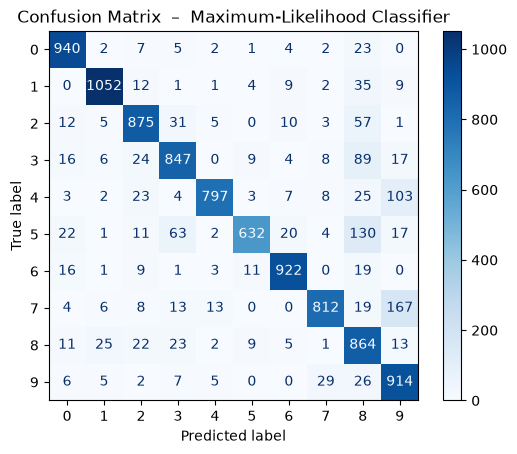

In [9]:
# --------------------------------------------------------------------
# 5.  Confusion matrix
# --------------------------------------------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix  –  Maximum‑Likelihood Classifier')
plt.show()

In [10]:
# --------------------------------------------------------------------
# 6.  Animation — correct inferences
# --------------------------------------------------------------------
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

correct_mask   = y_pred == y_test
correct_idx    = np.where(correct_mask)[0]

n_show = min(80, len(correct_idx))
show   = correct_idx[:n_show]

fig, ax = plt.subplots(figsize=(4, 4))
img_disp = ax.imshow(np.zeros((28, 28)), cmap='gray', vmin=0, vmax=1)
title    = ax.set_title('')
ax.axis('off')

def update(frame):
    i = show[frame]
    img_disp.set_data(X_test_norm[i].reshape(28, 28))
    title.set_text(f'True: {y_test[i]}   |   Pred: {y_pred[i]}')
    return img_disp, title

ani = FuncAnimation(fig, update, frames=n_show, interval=300, blit=False, repeat=True)
plt.close()
HTML(ani.to_jshtml())

In [11]:
# --------------------------------------------------------------------
# 7.  Animation — prediction errors
# --------------------------------------------------------------------

error_mask = y_pred != y_test
error_idx  = np.where(error_mask)[0]

n_show = min(80, len(error_idx))
show   = error_idx[:n_show]

fig, ax = plt.subplots(figsize=(4, 4))
img_disp = ax.imshow(np.zeros((28, 28)), cmap='gray', vmin=0, vmax=1)
title    = ax.set_title('', color='red', fontweight='bold')
ax.axis('off')

def update(frame):
    i = show[frame]
    img_disp.set_data(X_test_norm[i].reshape(28, 28))
    title.set_text(f'True: {y_test[i]}   |   Pred (WRONG): {y_pred[i]}')
    return img_disp, title

ani = FuncAnimation(fig, update, frames=n_show, interval=400, blit=False, repeat=True)
plt.close()
HTML(ani.to_jshtml())